## Pizza Sales Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
orders = pd.read_csv(r"C:\Users\HP 650 G5\Documents\WindowsPowerShell\orders.csv")

In [3]:
order_details = pd.read_csv(r"C:\Users\HP 650 G5\Documents\WindowsPowerShell\order_details.csv")

In [4]:
pizza = pd.read_csv(r"C:\Users\HP 650 G5\Documents\WindowsPowerShell\pizzas.csv")

In [5]:
pizza_types = pd.read_csv(r"C:\Users\HP 650 G5\Documents\WindowsPowerShell\pizza_types.csv",encoding="latin1")

### Data Cleaning

In [6]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [7]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [8]:
pizza.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [9]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [10]:
pizza_types.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   pizza_type_id  32 non-null     str  
 1   name           32 non-null     str  
 2   category       32 non-null     str  
 3   ingredients    32 non-null     str  
dtypes: str(4)
memory usage: 1.1 KB


In [11]:
pizza_types.isna().sum()

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

In [12]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   order_id  21350 non-null  int64
 1   date      21350 non-null  str  
 2   time      21350 non-null  str  
dtypes: int64(1), str(2)
memory usage: 500.5 KB


In [13]:
orders.isna().sum()

order_id    0
date        0
time        0
dtype: int64

In [14]:
order_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_details_id  48620 non-null  int64
 1   order_id          48620 non-null  int64
 2   pizza_id          48620 non-null  str  
 3   quantity          48620 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [15]:
order_details.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [16]:
pizza.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     str    
 1   pizza_type_id  96 non-null     str    
 2   size           96 non-null     str    
 3   price          96 non-null     float64
dtypes: float64(1), str(3)
memory usage: 3.1 KB


In [17]:
pizza.isna().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

### Merging DataFrames With Common Column for Analysis

In [18]:
df1 = pd.merge(orders, order_details, on='order_id', how='inner')
df1

,order_id,date,time,order_details_id,pizza_id,quantity
0,1,2015-01-01,11:38:36,1,hawaiian_m,1
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1
2,2,2015-01-01,11:57:40,3,five_cheese_l,1
3,2,2015-01-01,11:57:40,4,ital_supr_l,1
4,2,2015-01-01,11:57:40,5,mexicana_m,1
...,...,...,...,...,...,...
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1


In [19]:
df2 = pd.merge(df1, pizza, on='pizza_id', how='inner')
df2

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00
...,...,...,...,...,...,...,...,...,...
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1,ckn_alfredo,M,16.75
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1,four_cheese,L,17.95
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1,napolitana,S,12.00
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1,mexicana,L,20.25


In [20]:
df3 = pd.merge(df2, pizza_types, on='pizza_type_id', how='inner')
df3

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


### Total Revenue/Sales

In [21]:
df3['revenue'] = df3['quantity'] * df3['price']

total_revenue_sales = df3['revenue'].sum()

total_revenue_sales

np.float64(817860.0499999999)

### Total Quantity Sold

In [22]:
total_quantity_sold = df3['quantity'].sum()

total_quantity_sold

np.int64(49574)

### Total Orders

In [23]:
total_orders = df3['order_id'].nunique()

total_orders

21350

### Pizza Types Sold

In [24]:
total_types_of_pizza = df3['pizza_type_id'].nunique()

total_types_of_pizza

32

### Average pizza Price

In [25]:
average_pizza_price = df3['price'].mean()

average_pizza_price

np.float64(16.494132044426163)

### Peak Hours of Sales

In [26]:
df3['hour'] = pd.to_datetime(df3['time']).dt.hour

In [27]:
peak_hours = df3.groupby('hour')['quantity'].sum().sort_values(ascending=False).reset_index()

peak_hours

,hour,quantity
0,12,6776
1,13,6413
2,18,5417
3,17,5211
4,19,4406
5,16,4239
6,14,3613
7,20,3534
8,15,3216
9,11,2728


In [28]:
df3.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue,hour
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11


In [29]:
df3['day'] = pd.to_datetime(df3['date']).dt.day_name()

df3.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


### Total Sales by Each Week Day

In [30]:
daily_total_sales = df3.groupby('day')['quantity'].sum().reset_index()

daily_total_sales

,day,quantity
0,Friday,8242
1,Monday,6485
2,Saturday,7493
3,Sunday,6035
4,Thursday,7478
5,Tuesday,6895
6,Wednesday,6946


### Top selling Day

In [31]:
day_with_highest_sales = df3.groupby('day')['quantity'].sum().sort_values(ascending=False).reset_index().head(1)

day_with_highest_sales

,day,quantity
0,Friday,8242


##### Friday Has the Highest Sales

In [32]:
df3.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


### Top 5 Best selling Pizzas

In [33]:
top_5_best_selling_pizzas = df3.groupby('pizza_type_id')['quantity'].sum().reset_index().sort_values(by='quantity',
                                                                                                ascending=False).head()

top_5_best_selling_pizzas

,pizza_type_id,quantity
7,classic_dlx,2453
0,bbq_ckn,2432
11,hawaiian,2422
19,pepperoni,2418
29,thai_ckn,2371


### Sales Made in Each Month

In [34]:
df3['month'] = pd.to_datetime(df3['date']).dt.month_name()

df3.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day,month
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,January
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday,January
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday,January
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday,January
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday,January


In [35]:
#sales made in each month
total_monthly_sales = df3.groupby('month')['quantity'].sum().reset_index()

total_monthly_sales

,month,quantity
0,April,4151
1,August,4168
2,December,3935
3,February,3961
4,January,4232
5,July,4392
6,June,4107
7,March,4261
8,May,4328
9,November,4266


In [36]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September'
               'October', 'November', 'December']

In [37]:
df3['month'] = pd.Categorical(df3['month'], categories=months_order, ordered=True)

In [38]:
arrange_monthly_sales = df3.groupby('month', observed=False)['quantity'].sum().reset_index().sort_values('month')

arrange_monthly_sales

,month,quantity
0,January,4232
1,February,3961
2,March,4261
3,April,4151
4,May,4328
5,June,4107
6,July,4392
7,August,4168
8,SeptemberOctober,0
9,November,4266


### To Notice Trend

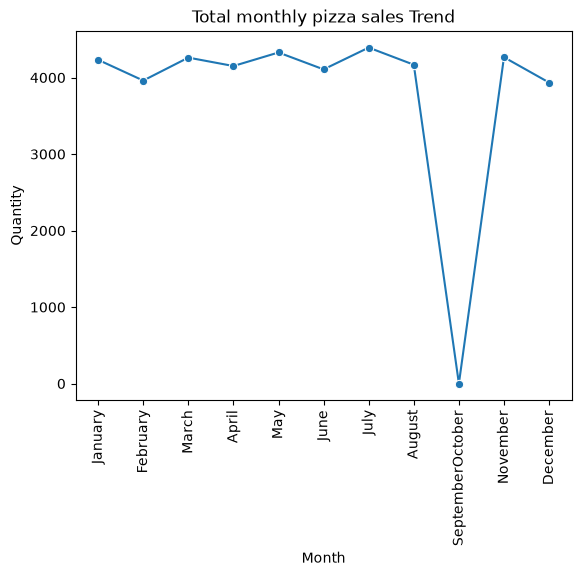

In [39]:
sns.lineplot(data=arrange_monthly_sales, x='month', y='quantity', marker='o')
plt.title('Total monthly pizza sales Trend')
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.xticks(rotation=90)

plt.show()

#### From The Above Figure, There's no trend

## Looking For pizza types with low sales below

In [40]:
pizzas_sales = df3.groupby('pizza_type_id')['quantity'].sum().reset_index().sort_values(by='quantity',
                                                                                                ascending=False)

pizzas_sales

,pizza_type_id,quantity
7,classic_dlx,2453
0,bbq_ckn,2432
11,hawaiian,2422
19,pepperoni,2418
29,thai_ckn,2371
4,cali_ckn,2370
22,sicilian,1938
25,spicy_ital,1924
24,southw_ckn,1917
1,big_meat,1914


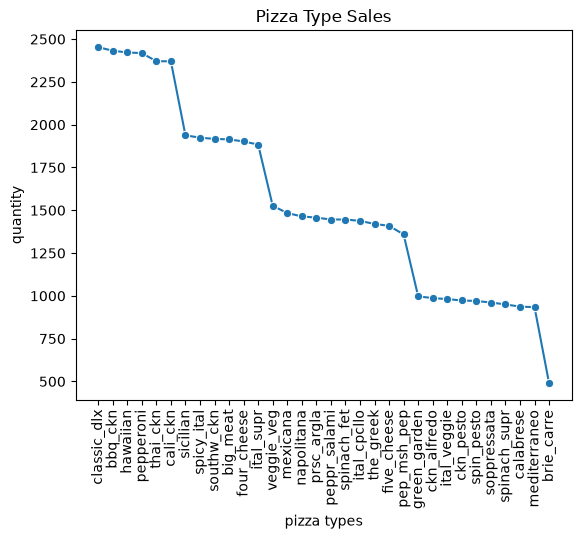

In [41]:
sns.lineplot(data=pizzas_sales, x='pizza_type_id', y='quantity', marker='o')
plt.title('Pizza Type Sales')
plt.xlabel('pizza types')
plt.ylabel('quantity')
plt.xticks(rotation=90)

plt.show()

### Pizza Types With Low Sales

In [42]:
pizzas_sales.tail()

,pizza_type_id,quantity
23,soppressata,961
28,spinach_supr,950
3,calabrese,937
15,mediterraneo,934
2,brie_carre,490
